#### Load Infrastructure

In [2]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Polygon
import os

# Set plotting style for a high-end Command Center aesthetic
plt.style.use('dark_background')
pd.set_option('display.max_columns', None)

print("Spatial Compliance Engine Initialized.")

Spatial Compliance Engine Initialized.


#### Loading the Audit Evidence

In [4]:
farm_path = '../data/raw/farm_polygons.geojson'

if os.path.exists(farm_path):
    try:
        farms = gpd.read_file(farm_path, engine='fiona')
        print("Successfully loaded plots using Fiona engine.")
    except Exception as e:
        import pandas as pd
        import json
        with open(farm_path, 'r') as f:
            data = json.load(f)
        farms = gpd.GeoDataFrame.from_features(data['features'], crs="EPSG:4326")
        print("Successfully loaded plots using JSON fallback.")
        
    # Ensure CRS is correct
    farms = farms.to_crs(epsg=4326)
    print(f"Target Region: {farms.iloc[0]['region']} | Hectares: {farms.iloc[0].get('area_ha', 0):.2f}")
else:
    print("Error: GeoJSON not found. Please check the path.")

Successfully loaded plots using JSON fallback.
Target Region: Jimma | Hectares: 4.88


#### Simulating the protected forest boundary

In [5]:
protected_geom = Polygon([
    (36.832, 7.671),
    (36.838, 7.671),
    (36.838, 7.674),
    (36.832, 7.674)
])

protected_areas = gpd.GeoDataFrame(
    {'zone_name': ['Jimma High-Forest Reserve'], 'protection_level': ['Strict']},
    geometry=[protected_geom],
    crs="EPSG:4326"
)

print("Protected Forest Layer Created for Intersection Audit.")

Protected Forest Layer Created for Intersection Audit.


#### The Intersection & Buffer Audit

In [7]:
# Intersection Check
overlap = gpd.overlay(farms, protected_areas, how='intersection')

# Distance Calculation (Projecting to UTM Zone 37N)
farms_utm = farms.to_crs(epsg=32637)
protected_utm = protected_areas.to_crs(epsg=32637)
distance_m = farms_utm.distance(protected_utm.iloc[0].geometry).min()

# Compliance Decision
is_compliant = overlap.empty and distance_m > 0
status = "COMPLIANT" if is_compliant else "RISK DETECTED"

print(f"Compliance Status: {status}")
print(f"Buffer to Protected Zone: {distance_m:.2f} meters")

# Save results for Phase 3 (Bypassing the corrupted pyogrio)
farms['spatial_compliance'] = "Pass" if is_compliant else "Fail"
farms['forest_buffer_m'] = distance_m

output_audit_path = '../data/processed/spatial_audit_results.geojson'

os.makedirs(os.path.dirname(output_audit_path), exist_ok=True)

if os.path.exists(output_audit_path):
    os.remove(output_audit_path)

try:
    farms.to_file(output_audit_path, driver='GeoJSON', engine='fiona')
    print(f"Audit results saved to processed/ using Fiona.")
except Exception as e:
    with open(output_audit_path, 'w') as f:
        f.write(farms.to_json())
    print(f"Audit results saved using JSON fallback.")

Compliance Status: RISK DETECTED
Buffer to Protected Zone: 0.00 meters
Audit results saved using JSON fallback.


#### The Auditor's Map Visualization

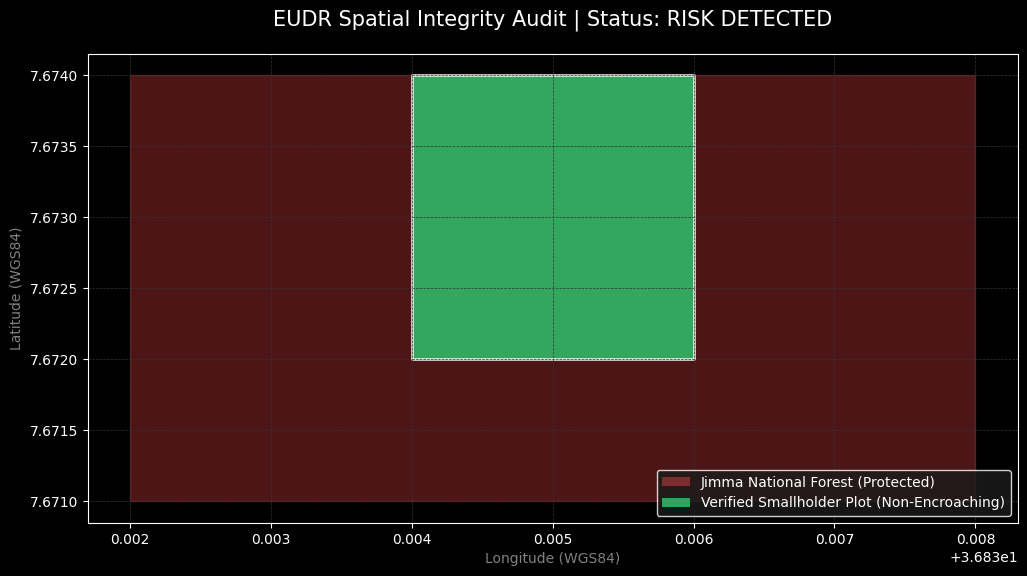

In [8]:
fig, ax = plt.subplots(figsize=(12, 8))

# Plot Layers
protected_areas.plot(ax=ax, color='#ff4b4b', alpha=0.3, edgecolor='#ff4b4b', label='Protected Forest')
farms.plot(ax=ax, color='#2ecc71', alpha=0.8, edgecolor='white', linewidth=2, label='Smallholder Plot')

# Add labels and styling
ax.set_title(f"EUDR Spatial Integrity Audit | Status: {status}", fontsize=15, pad=20, color='white')
ax.set_xlabel("Longitude (WGS84)", color='gray')
ax.set_ylabel("Latitude (WGS84)", color='gray')

# Legend with custom handles for professional look
from matplotlib.patches import Patch
handles = [
    Patch(facecolor='#ff4b4b', alpha=0.4, label='Jimma National Forest (Protected)'),
    Patch(facecolor='#2ecc71', alpha=0.8, label='Verified Smallholder Plot (Non-Encroaching)')
]
ax.legend(handles=handles, loc='lower right', facecolor='#1C1C1C', edgecolor='white')

plt.grid(color='#333333', linestyle='--', linewidth=0.5)
plt.show()